<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Multivariate_Occupancy_RNN.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 9 — Multivariate RNN Pt 1: split_sequences, column order, the classification head
- Multivariate differs only in prep: all X on the left, TARGET AS THE LAST COLUMN (drop the date); look-back is the hyperparameter.
- split_sequences with look-back 10 -> 2,655 samples of 10 x features; the -1 predicts the NEXT step.
- SimpleRNN with a sigmoid head, n_steps / n_features inherited from the shape; if it learns in one epoch, add dropout.
- Show the time-series plot even for classification - it misses the quick in/out transitions.
-->


# Multivariate Occupancy Example (RNN), Part 1: Classify the Room
----------------------------
**Dr. Dave Wanik - University of Connecticut**

Let's see if we can predict whether a room is occupied as a function of its environmental sensor data (temperature, humidity, light, CO2).

Link: http://archive.ics.uci.edu/ml/datasets/Occupancy+Detection+

Same flow as before, just need to prep our data differently. For now, we ignore the time dimension but we could resample to a regular resolution.

Wow - also a nice example: https://machinelearningmastery.com/multivariate-time-series-forecasting-lstms-keras/

In [1]:
# standard modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# RNN-specific modules
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report,accuracy_score
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility: same seed every run (numbers on CPU match exactly; a GPU may drift a little)
import keras
keras.utils.set_random_seed(5509)


## Read in data
Check for missing values, make some plots.

In [2]:
# Dataset: UCI room-occupancy detection (Candanedo & Feldheim, 2016), originally from LuisM78's GitHub.
# We use the two real files - 8,143 minutes of training data (Feb 4-10) followed by 9,752 of test (Feb 11-18) -
# stacked in date order into one two-week series. (The 2-day datatest.txt slice was too short to learn from.)
base = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/"
df = pd.concat([pd.read_csv(base + "datatraining.txt"), pd.read_csv(base + "datatest2.txt")], ignore_index=True)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)   # chronological - never shuffle a time series
print(df.info())
df.head(n=15) # nice complete data! this will allow us to check our work later

<class 'pandas.DataFrame'>
RangeIndex: 17895 entries, 0 to 17894
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           17895 non-null  datetime64[us]
 1   Temperature    17895 non-null  float64       
 2   Humidity       17895 non-null  float64       
 3   Light          17895 non-null  float64       
 4   CO2            17895 non-null  float64       
 5   HumidityRatio  17895 non-null  float64       
 6   Occupancy      17895 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 978.8 KB
None


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-04 17:51:00,23.180,27.272000,426.0,721.250000,0.004793,1
1,2015-02-04 17:51:59,23.150,27.267500,429.5,714.000000,0.004783,1
2,2015-02-04 17:53:00,23.150,27.245000,426.0,713.500000,0.004779,1
3,2015-02-04 17:54:00,23.150,27.200000,426.0,708.250000,0.004772,1
4,2015-02-04 17:55:00,23.100,27.200000,426.0,704.500000,0.004757,1
5,2015-02-04 17:55:59,23.100,27.200000,419.0,701.000000,0.004757,1
6,2015-02-04 17:57:00,23.100,27.200000,419.0,701.666667,0.004757,1
7,2015-02-04 17:57:59,23.100,27.200000,419.0,699.000000,0.004757,1
8,2015-02-04 17:58:59,23.100,27.200000,419.0,689.333333,0.004757,1
9,2015-02-04 18:00:00,23.075,27.175000,419.0,688.000000,0.004745,1


In [3]:
# count of occupancy
df['Occupancy'].value_counts() # not perfectly balanced, but that's OK

Occupancy
0    14117
1     3778
Name: count, dtype: int64

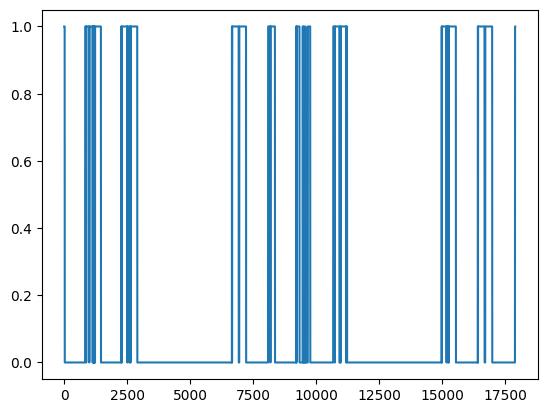

In [4]:
# visualize the data
df['Occupancy'].plot()
plt.show()

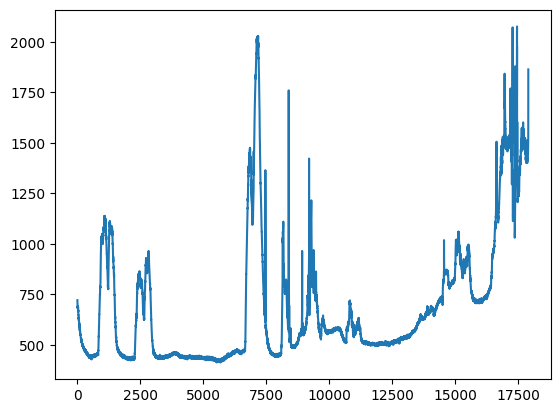

In [5]:
# visualize the data
df['CO2'].plot()
plt.show()

In [6]:
# drop the date column
df.drop(['date'], inplace=True, axis=1)
print(df.shape)
df.head()

(17895, 6)


,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,23.18,27.2720,426.0,721.25,0.004793,1
1,23.15,27.2675,429.5,714.00,0.004783,1
2,23.15,27.2450,426.0,713.50,0.004779,1
3,23.15,27.2000,426.0,708.25,0.004772,1
4,23.10,27.2000,426.0,704.50,0.004757,1


<!-- WINDOW-FN -->
## The window-making function: `split_sequences`

The multivariate version. Put the **target in the last column** first, then:

- **`n_steps`** is the **look-back**: each X is the last `n_steps` rows of **every column except the target**, shaped `(n_steps, n_features)`.
- The target y is the **last column at the final row of the window**, the same moment as the newest inputs.

For occupancy that's a **nowcast**: the sensors up to this minute say whether the room is occupied this minute.

Result: X is `(samples, n_steps, n_features)`, exactly what `input_shape=(n_steps, n_features)` expects.


In [7]:
# prep data for modeling (multivariate)
# link: https://machinelearningmastery.com/how-to-develop-lstm-models-for-time-series-forecasting/

from numpy import array

# split a multivariate sequence into samples
def split_sequences(sequences, n_steps):
	X, y = list(), list()
	for i in np.arange(len(sequences)): # be careful of this line!
		# find the end of this pattern
		end_ix = i + n_steps
		# check if we are beyond the dataset
		if end_ix > len(sequences):
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
		X.append(seq_x)
		y.append(seq_y)
	return np.array(X), np.array(y)

In [8]:
# we could split our data first, normalize it, then create sequences

In [9]:
# all we need to do is decide on is n_steps (what our lookback period is)
# since we have a bunch of data, why not n_steps=10? then try 30 later on.
n_steps = 10
raw_seq = np.array(df) #make sure your data is stored as a numpy array!
# let's ignore the date column and just use the temperature data
X, y = split_sequences(raw_seq, n_steps=10)

In [10]:
# take a peak at what it did
print(X.shape)
print(y.shape)

# scroll up and make sure you understand this!
# y is a function of X (the previous n_steps observations!)

(17886, 10, 5)
(17886,)


In [11]:
# check the first few values
X[0]

array([[2.31800000e+01, 2.72720000e+01, 4.26000000e+02, 7.21250000e+02,
        4.79298818e-03],
       [2.31500000e+01, 2.72675000e+01, 4.29500000e+02, 7.14000000e+02,
        4.78344095e-03],
       [2.31500000e+01, 2.72450000e+01, 4.26000000e+02, 7.13500000e+02,
        4.77946352e-03],
       [2.31500000e+01, 2.72000000e+01, 4.26000000e+02, 7.08250000e+02,
        4.77150883e-03],
       [2.31000000e+01, 2.72000000e+01, 4.26000000e+02, 7.04500000e+02,
        4.75699293e-03],
       [2.31000000e+01, 2.72000000e+01, 4.19000000e+02, 7.01000000e+02,
        4.75699293e-03],
       [2.31000000e+01, 2.72000000e+01, 4.19000000e+02, 7.01666667e+02,
        4.75699293e-03],
       [2.31000000e+01, 2.72000000e+01, 4.19000000e+02, 6.99000000e+02,
        4.75699293e-03],
       [2.31000000e+01, 2.72000000e+01, 4.19000000e+02, 6.89333333e+02,
        4.75699293e-03],
       [2.30750000e+01, 2.71750000e+01, 4.19000000e+02, 6.88000000e+02,
        4.74535072e-03]])

In [12]:
# check Y
y[0]

np.float64(1.0)

## What exactly is one sample?

Say it out loud once and the rest of the notebook follows:

> **One sample is a ten-minute clip of the five sensors, and the model's job is to answer one question about it:
> was the room occupied at the *end* of the clip?**

That is what `split_sequences` just built, and two details in it catch everybody:

**1. The label is the LAST minute, not the whole window.** `y` comes from `sequences[end_ix-1, -1]` - the final row.
The other nine minutes are *context*, not answers. So a clip that starts empty and ends occupied is labelled
**occupied**, and that is not a mistake or an ambiguity: it is a clip of someone walking in.

**2. Occupancy is never an input.** `sequences[i:end_ix, :-1]` drops the last column, so the model sees the five
sensors and nothing else. It cannot peek at whether the room was occupied a minute ago. That is why the persistence
baseline - which *can* - is so hard to beat here, and it is the honest weakness of this dataset.

The cell below prints one sample so you can see the shape, then prints the case that catches people out.

In [13]:
sensors = list(df.columns[:-1])                      # the 5 inputs; Occupancy is the target, not an input
idx = [f"t-{n_steps-1-i}" for i in range(n_steps)]   # t-9 (oldest) ... t-0 (the minute being classified)

print("X shape", X.shape, "= (samples, minutes, sensors)   y shape", y.shape)
print()
print(f"one sample - X[0] - is a {n_steps} x {len(sensors)} block:")
display(pd.DataFrame(X[0], columns=sensors, index=idx).round(2))
print(f"and its label is y[0] = {y[0]:.0f}  <- occupancy at t-0 ONLY")

# the case that catches people out: the room changes state partway through the window
occ  = df["Occupancy"].values
wins = np.lib.stride_tricks.sliding_window_view(occ, n_steps)
m = int(np.argmax(wins.min(axis=1) != wins.max(axis=1)))
print()
print(f"window {m}, minute by minute: {wins[m].astype(int)}")
print(f"its label is {wins[m][-1]:.0f} - occupied for nine minutes, but the label is always the LAST minute.")

X shape (17886, 10, 5) = (samples, minutes, sensors)   y shape (17886,)

one sample - X[0] - is a 10 x 5 block:


,Temperature,Humidity,Light,CO2,HumidityRatio
t-9,23.18,27.27,426.0,721.25,0.0
t-8,23.15,27.27,429.5,714.00,0.0
t-7,23.15,27.24,426.0,713.50,0.0
t-6,23.15,27.20,426.0,708.25,0.0
t-5,23.10,27.20,426.0,704.50,0.0
t-4,23.10,27.20,419.0,701.00,0.0
t-3,23.10,27.20,419.0,701.67,0.0
t-2,23.10,27.20,419.0,699.00,0.0
t-1,23.10,27.20,419.0,689.33,0.0
t-0,23.08,27.18,419.0,688.00,0.0


and its label is y[0] = 1  <- occupancy at t-0 ONLY

window 7, minute by minute: [1 1 1 1 1 1 1 1 1 0]
its label is 0 - occupied for nine minutes, but the label is always the LAST minute.


In [14]:
# split the data into train and test partitions
# we will use 50% of the data for train, and 50% for validation
train_pct_index = int(0.5 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = y[:train_pct_index], y[train_pct_index:]

# pretty slick way of splitting your data using slicing!
# notice how we didn't do any shuffling (we don't want temporal leakage! keeps time series intact)

In [15]:
# check the shape to be sure
print(X.shape, X_train.shape, X_test.shape)
print(y.shape, y_train.shape, y_test.shape)

# verify that this all adds up!
# 2635 samples with 30 lookback and 6 columns

(17886, 10, 5) (8943, 10, 5) (8943, 10, 5)
(17886,) (8943,) (8943,)


## One helper to score every model

Every model below gets the same treatment, so they are comparable: **train and test**, the F1 for each, the test
confusion matrix, and two pictures.

The important choice here is that we plot **`model.predict()` directly - the probability - and never the rounded
class**. Rounding to 0/1 throws away the only interesting part, which is *how sure the model was*. A model that
says 0.51 and a model that says 0.99 both round to "occupied", and you want to be able to tell them apart.

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

scores = {}          # weighted F1
macro  = {}          # macro F1 - the score that notices the smaller class

def show_results(name, model):
    """Score a model on train and test, then plot the probability it reports over time.
    We plot model.predict() directly - the probability - not the rounded class."""
    p_tr = model.predict(X_train, verbose=0).ravel()
    p_te = model.predict(X_test,  verbose=0).ravel()
    pred = (p_te >= 0.5).astype(int)
    scores[name] = f1_score(y_test, pred, average="weighted")
    macro[name]  = f1_score(y_test, pred, average="macro")

    print(name)
    print(f"train F1: {f1_score(y_train, (p_tr >= 0.5).astype(int), average='weighted'):.3f}"
          f"    test F1: {scores[name]:.3f}")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, digits=3))

    CHUNK = 1500                        # minutes per row, so the whole split fits on screen
    for split, y_true, p in [("train", y_train, p_tr), ("test", y_test, p_te)]:
        nrow = int(np.ceil(len(y_true) / CHUNK))
        fig, ax = plt.subplots(nrow, 1, figsize=(12, 1.5 * nrow), squeeze=False)
        for k in range(nrow):
            sl = slice(k * CHUNK, min((k + 1) * CHUNK, len(y_true)))
            t = np.arange(len(y_true))[sl]
            ax[k][0].fill_between(t, 0, y_true[sl], step="mid", color="#C8E6C9",
                                  label="actually occupied" if k == 0 else None)
            ax[k][0].plot(t, p[sl], color="#C62828", lw=0.9,
                          label="P(occupied)" if k == 0 else None)
            ax[k][0].axhline(0.5, color="#616161", ls="--", lw=0.7)
            ax[k][0].set_ylim(-0.05, 1.05); ax[k][0].set_yticks([0, 0.5, 1])
            ax[k][0].set_xlim(k * CHUNK, (k + 1) * CHUNK)
        ax[0][0].legend(loc="upper center", ncol=2, fontsize=8)
        ax[-1][0].set_xlabel("minute")
        fig.suptitle(f"{name} - {split}", y=1.0)
        plt.tight_layout(); plt.show()

In [17]:
def metrics_table(y_true_cls, y_pred_cls, labels=("empty", "occupied")):
    """Every intermediate number behind accuracy / macro F1 / weighted F1 - shown, not asserted."""
    y_true_cls = np.asarray(y_true_cls).astype(int).ravel()
    y_pred_cls = np.asarray(y_pred_cls).astype(int).ravel()
    rows = []
    for k, cname in enumerate(labels):
        tp = int(((y_pred_cls == k) & (y_true_cls == k)).sum())
        fp = int(((y_pred_cls == k) & (y_true_cls != k)).sum())
        fn = int(((y_pred_cls != k) & (y_true_cls == k)).sum())
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec  = tp / (tp + fn) if tp + fn else 0.0
        f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        n_c  = int((y_true_cls == k).sum())
        rows.append({"class": cname, "TP": tp, "FP": fp, "FN": fn,
                     "precision": round(prec, 4), "recall": round(rec, 4), "F1": round(f1, 4),
                     "support n_c": n_c, "n_c x F1": round(n_c * f1, 1)})
    t = pd.DataFrame(rows).set_index("class")
    N = int(t["support n_c"].sum()); correct = int((y_pred_cls == y_true_cls).sum())
    macro = t["F1"].mean(); weighted = t["n_c x F1"].sum() / N
    display(t)
    print(f"accuracy    = correct / all     = {correct:,} / {N:,} = {correct/N:.4f}")
    print(f"macro F1    = (F1_0 + F1_1) / 2 = ({t['F1'].iloc[0]:.4f} + {t['F1'].iloc[1]:.4f}) / 2 = {macro:.4f}")
    print(f"weighted F1 = sum(n_c x F1) / N = {t['n_c x F1'].sum():,.1f} / {N:,} = {weighted:.4f}")
    return {"accuracy": correct/N, "macro F1": macro, "weighted F1": weighted}

> **

### Reading the classification report

Three numbers get reported and they answer three different questions. Everything comes out of the confusion matrix:

|  | predicted empty | predicted occupied |
| :-- | :-: | :-: |
| **was empty** | TN | FP |
| **was occupied** | FN | TP |

**Per class**, "precision" is how often it was right when it said so, and "recall" is how much of the class it
caught. $F_1$ is their harmonic mean, which punishes a model that buys one by giving up the other:

$$
\text{precision} = \frac{TP}{TP + FP}, \qquad
\text{recall} = \frac{TP}{TP + FN}, \qquad
F_1 = 2\,\frac{\text{precision}\cdot\text{recall}}{\text{precision} + \text{recall}}
$$

**Accuracy** ignores classes entirely - it is just the share of rows on the diagonal:

$$
\text{accuracy} = \frac{TP + TN}{\text{all windows}}
$$

**The two averages** differ only in what they weight by. Let $n_c$ be the **support** of class $c$ - how many test
windows actually belong to it:

$$
\text{macro } F_1 = \frac{1}{C}\sum_{c} F_1^{(c)}
\qquad\qquad
\text{weighted } F_1 = \frac{\sum_c n_c\,F_1^{(c)}}{\sum_c n_c}
$$

**Macro treats the two classes as equally important.** **Weighted treats every window as equally important**, so
the big class dominates it.

#### Worked, with this notebook's LSTM

| class | precision | recall | $F_1$ | support |
| :-- | --: | --: | --: | --: |
| empty | 0.972 | 0.968 | 0.970 | 7,108 |
| occupied | 0.878 | 0.892 | 0.885 | 1,835 |

$$
\text{macro } F_1 = \frac{0.970 + 0.885}{2} = 0.9275 \approx \mathbf{0.928}
$$

$$
\text{weighted } F_1 = \frac{0.970(7{,}108) + 0.885(1{,}835)}{8{,}943} = \frac{8{,}519}{8{,}943} = \mathbf{0.953}
$$

Weighted comes out higher because the class the model is better at is also the class that is four times bigger.

#### Why we bother reporting all three

Put the majority-class baseline - the one that never says "occupied" - next to the LSTM:

| model | accuracy | weighted $F_1$ | macro $F_1$ |
| :-- | --: | --: | --: |
| always guess "empty" | 0.795 | 0.704 | **0.443** |
| LSTM(30) | 0.952 | 0.953 | **0.928** |

**Accuracy says the useless model is 80% right.** Weighted $F_1$ is suspicious of it. **Macro $F_1$ exposes it**,
because the occupied class scores $F_1 = 0$ and macro refuses to let the big class hide that.

Rule of thumb: on imbalanced data, quote **macro** when both classes matter to you - and for a room-occupancy
sensor, detecting the *occupied* minutes is the entire point.

# RNN one layer model

In [18]:
# define
n_steps = X_train.shape[1]
n_features = X_train.shape[2]

print(n_steps, n_features)

10 5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30)             │         1,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,111 (4.34 KB)

 Trainable params: 1,111 (4.34 KB)

 Non-trainable params: 0 (0.00 B)

...

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9758 - loss: 0.1521

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9759 - loss: 0.1488

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9744 - loss: 0.1485 - val_acc: 0.8765 - val_loss: 1.1336


Epoch 11: early stopping


Restoring model weights from the end of the best epoch: 1.


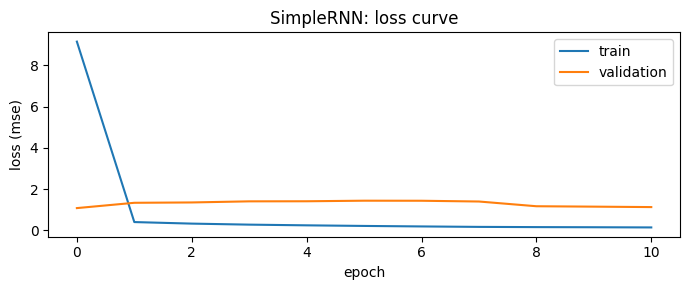

stopped after 11 epochs; best validation loss 1.085


In [19]:
# now let's build a model
# NEED TO UPDATE FOR CLASSIFICATION

# define
n_steps = X_train.shape[1]
n_features = X_train.shape[2]

# define model
model = Sequential()
model.add(Input(shape=(n_steps,n_features)))
model.add(SimpleRNN(30, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc'])


es = EarlyStopping(monitor='val_acc', mode='max',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=64,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("SimpleRNN: loss curve")
plt.legend(); plt.tight_layout(); plt.show()

print(f"stopped after {len(history.history['loss'])} epochs;"
      f" best validation loss {min(history.history['val_loss']):.3f}")

SimpleRNN(30)
train F1: 0.931    test F1: 0.952
[[6957  151]
 [ 270 1565]]
              precision    recall  f1-score   support

         0.0      0.963     0.979     0.971      7108
         1.0      0.912     0.853     0.881      1835

    accuracy                          0.953      8943
   macro avg      0.937     0.916     0.926      8943
weighted avg      0.952     0.953     0.952      8943



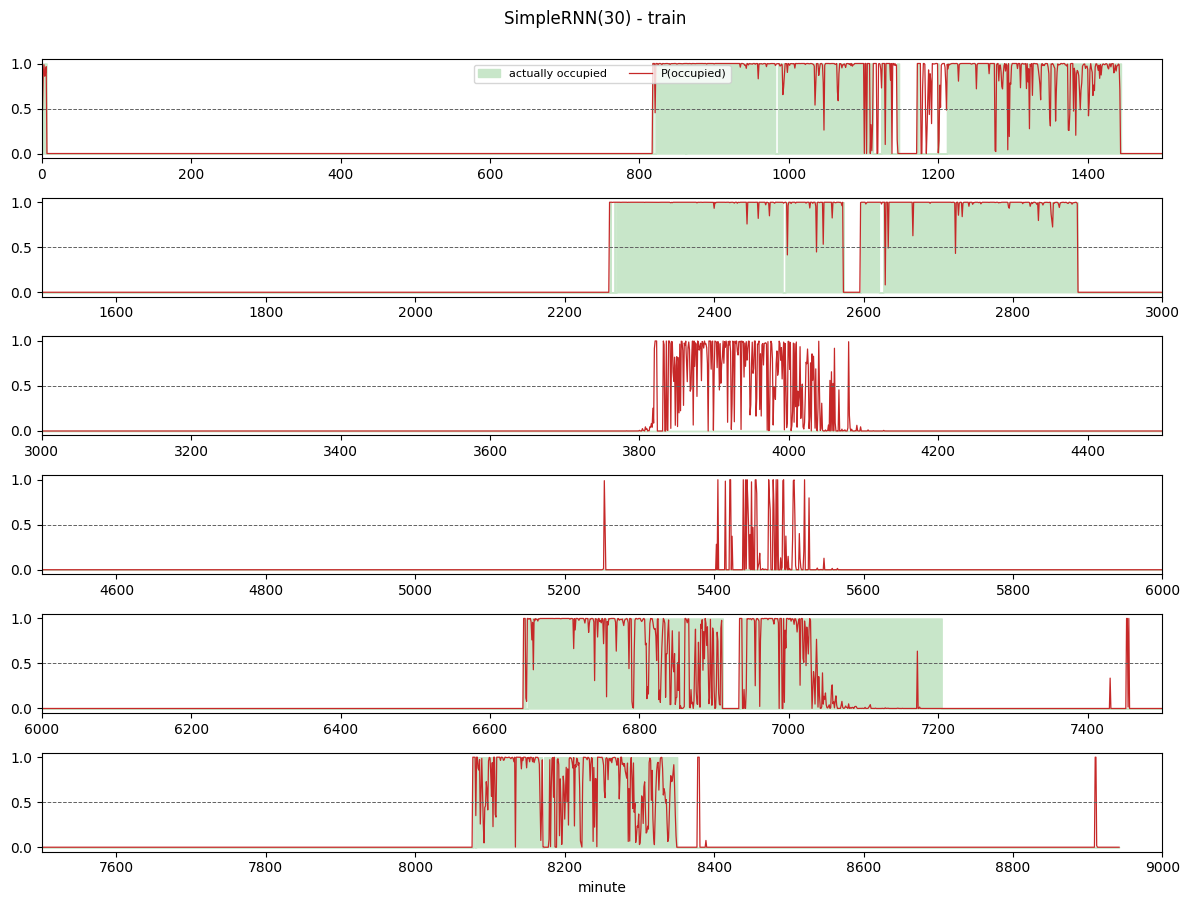

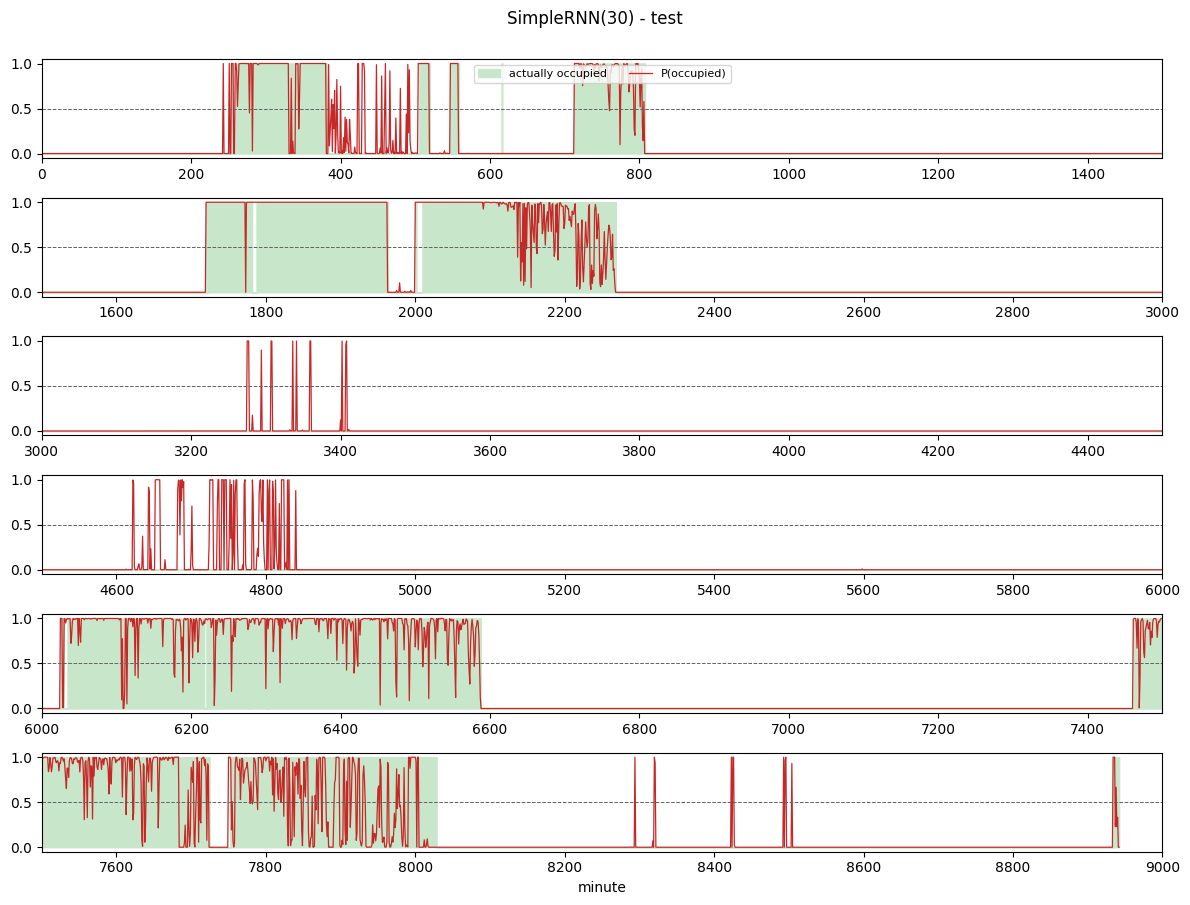

In [20]:
show_results("SimpleRNN(30)", model)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 10 — Multivariate RNN Pt 2: LSTM swap, stacking, persistence baseline
- One-word LSTM swap: (features + units) x units + bias, x4 = 4,320 params.
- It predicts the zeros a bit better; weighted F1 comparable.
- Stacked SimpleRNN with return_sequences=True keeps the 10 x 30 sequence into a second RNN - and does WORSE here: too complex for an easy problem.
- Persistence is brutal to beat - show value over the naive baseline every time.
-->


# LSTM one layer model
Literally, just grab the code above and change SimpleRNN to LSTM and boom! you have a more sophisticated model.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30)             │         4,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,351 (17.00 KB)

 Trainable params: 4,351 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

...

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9781 - loss: 0.1033

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9758 - loss: 0.1110

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.9762 - loss: 0.1119 - val_acc: 0.9743 - val_loss: 0.0768


Epoch 32: early stopping


Restoring model weights from the end of the best epoch: 22.


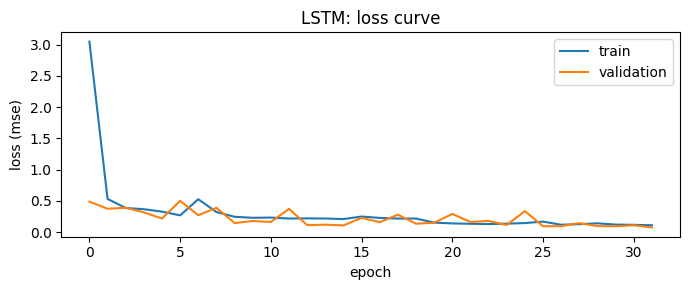

stopped after 32 epochs; best validation loss 0.077


In [21]:
# now let's build a model

# since this is a univariate problem, n_features will be 1 (we also defined this before)

# define model
model = Sequential()
model.add(Input(shape=(n_steps,n_features)))
model.add(LSTM(30, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc'])
model.summary()

es = EarlyStopping(monitor='val_acc',
                   mode='max',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=64,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("LSTM: loss curve")
plt.legend(); plt.tight_layout(); plt.show()

print(f"stopped after {len(history.history['loss'])} epochs;"
      f" best validation loss {min(history.history['val_loss']):.3f}")

LSTM(30)
train F1: 0.981    test F1: 0.953
[[6881  227]
 [ 198 1637]]
              precision    recall  f1-score   support

         0.0      0.972     0.968     0.970      7108
         1.0      0.878     0.892     0.885      1835

    accuracy                          0.952      8943
   macro avg      0.925     0.930     0.928      8943
weighted avg      0.953     0.952     0.953      8943



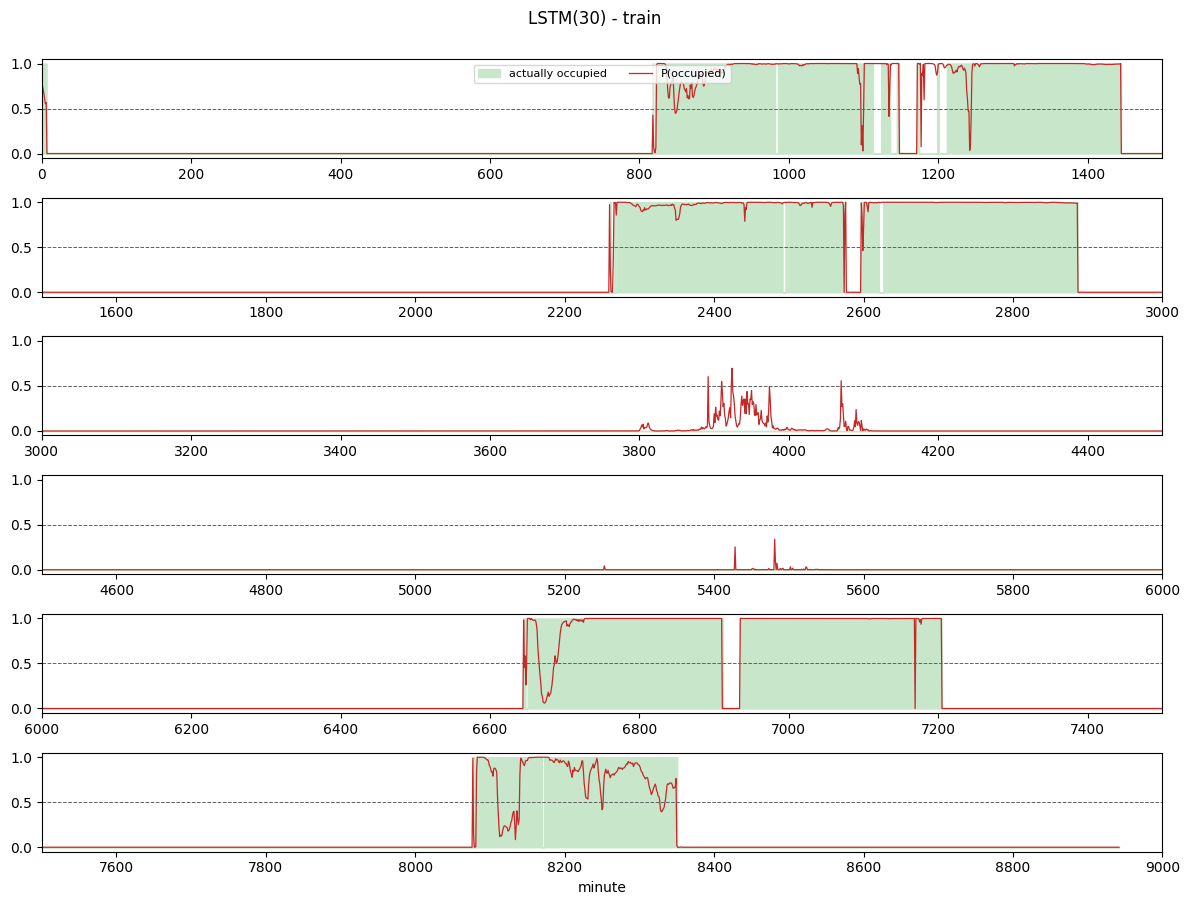

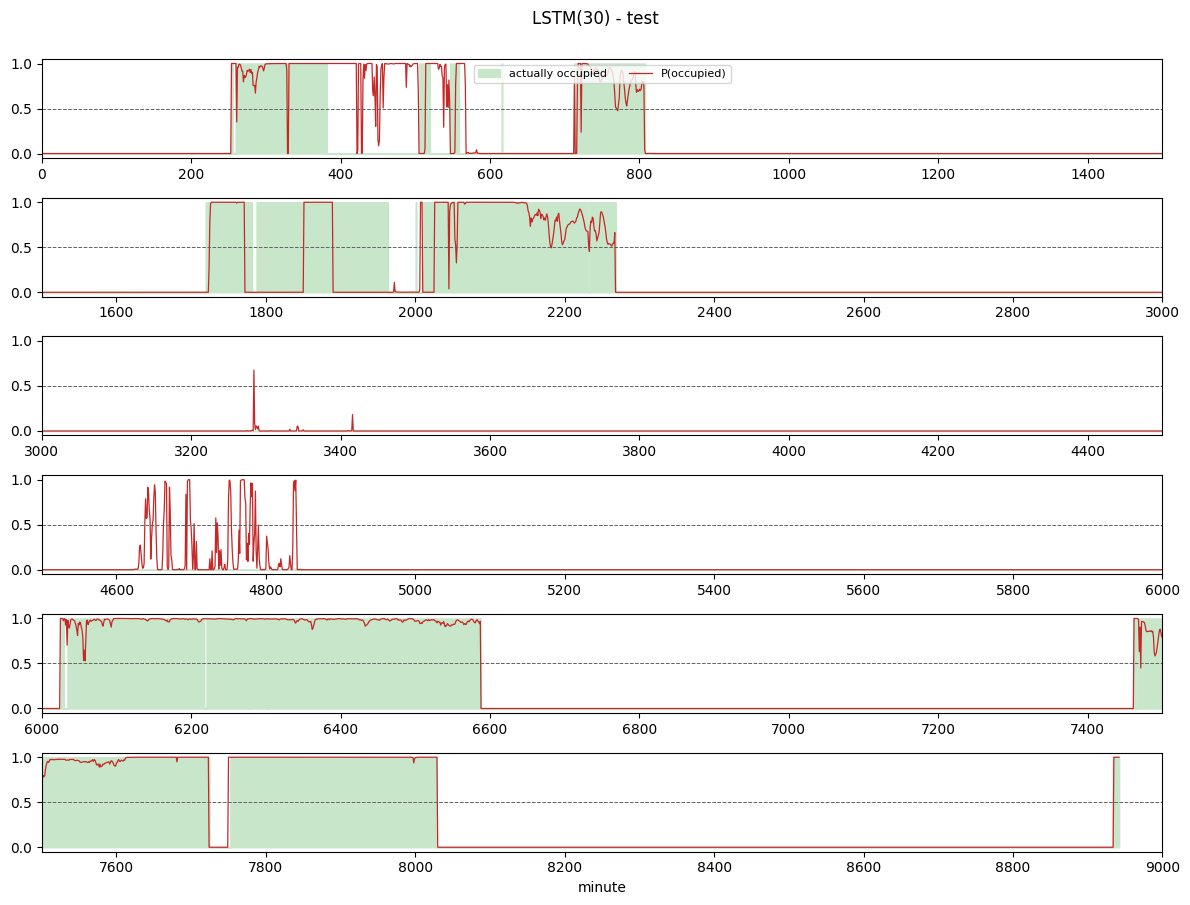

In [22]:
show_results("LSTM(30)", model)

# RNN two layer model
Don't forget to set return_sequences=True!

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 10, 30)         │         1,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,941 (11.49 KB)

 Trainable params: 2,941 (11.49 KB)

 Non-trainable params: 0 (0.00 B)

...

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9717 - loss: 0.0894

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9705 - loss: 0.0910

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.9698 - loss: 0.0916 - val_acc: 0.9732 - val_loss: 0.0528


Epoch 13: early stopping


Restoring model weights from the end of the best epoch: 3.


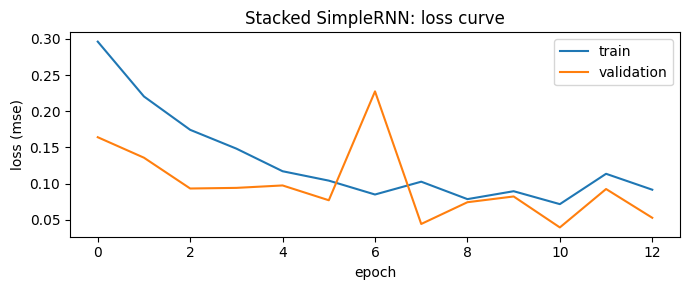

stopped after 13 epochs; best validation loss 0.039


In [23]:
# now let's build a model

# since this is a univariate problem, n_features will be 1 (we also defined this before)

# define model
model = Sequential()
model.add(Input(shape=(n_steps,n_features)))
model.add(SimpleRNN(30, return_sequences=True, activation='relu'))
                                    # note that the output when
                                    # return_sequences=True makes the output [n_steps, features]
                                    # where rows = n_steps (10!) and features = hidden size (30!)
model.add(SimpleRNN(30)) # output is a simple vector [1,30] that goes into a dense layer
                          # NO RETURN_SEQUENCES!!!
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc'])
model.summary()

es = EarlyStopping(monitor='val_acc', mode='max',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=64,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("Stacked SimpleRNN: loss curve")
plt.legend(); plt.tight_layout(); plt.show()

print(f"stopped after {len(history.history['loss'])} epochs;"
      f" best validation loss {min(history.history['val_loss']):.3f}")

stacked SimpleRNN(30) x2
train F1: 0.964    test F1: 0.941
[[6846  262]
 [ 266 1569]]
              precision    recall  f1-score   support

         0.0      0.963     0.963     0.963      7108
         1.0      0.857     0.855     0.856      1835

    accuracy                          0.941      8943
   macro avg      0.910     0.909     0.909      8943
weighted avg      0.941     0.941     0.941      8943



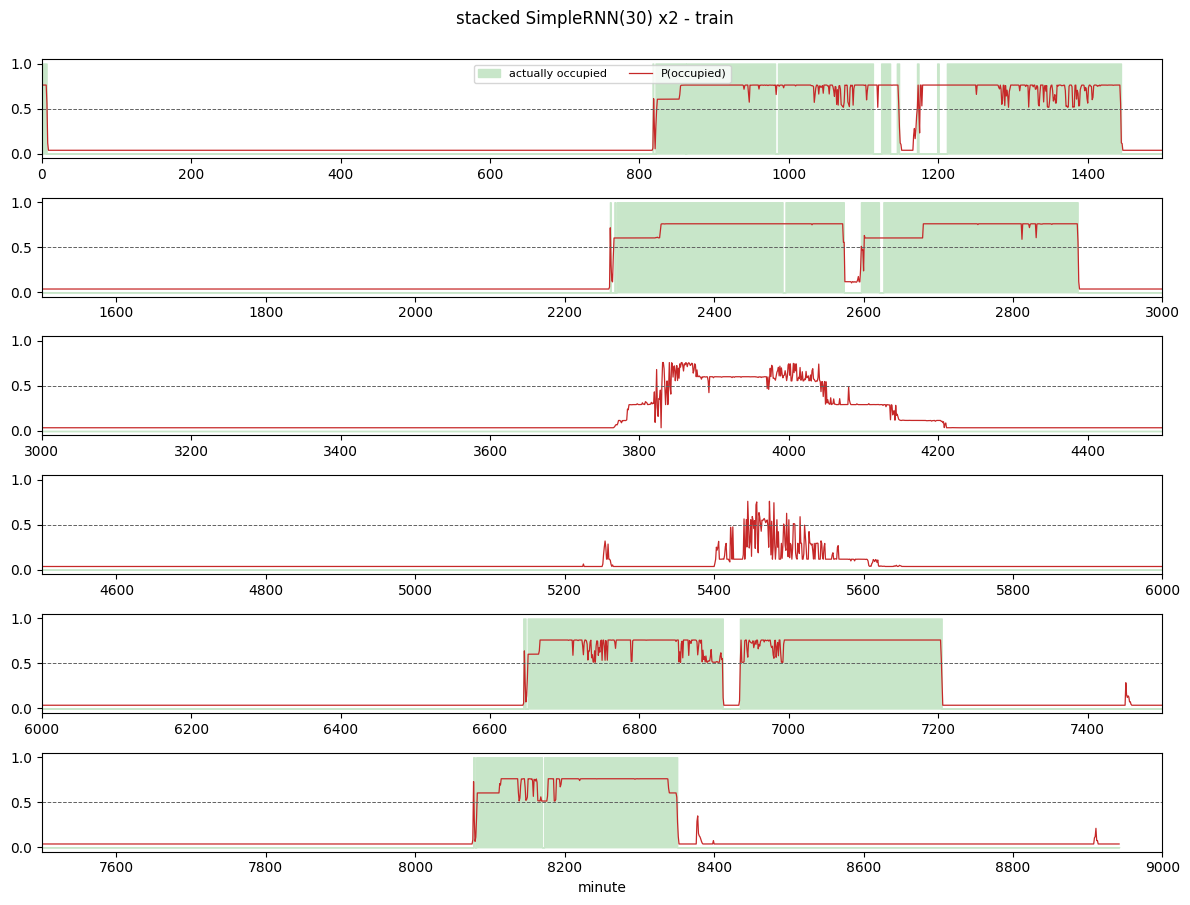

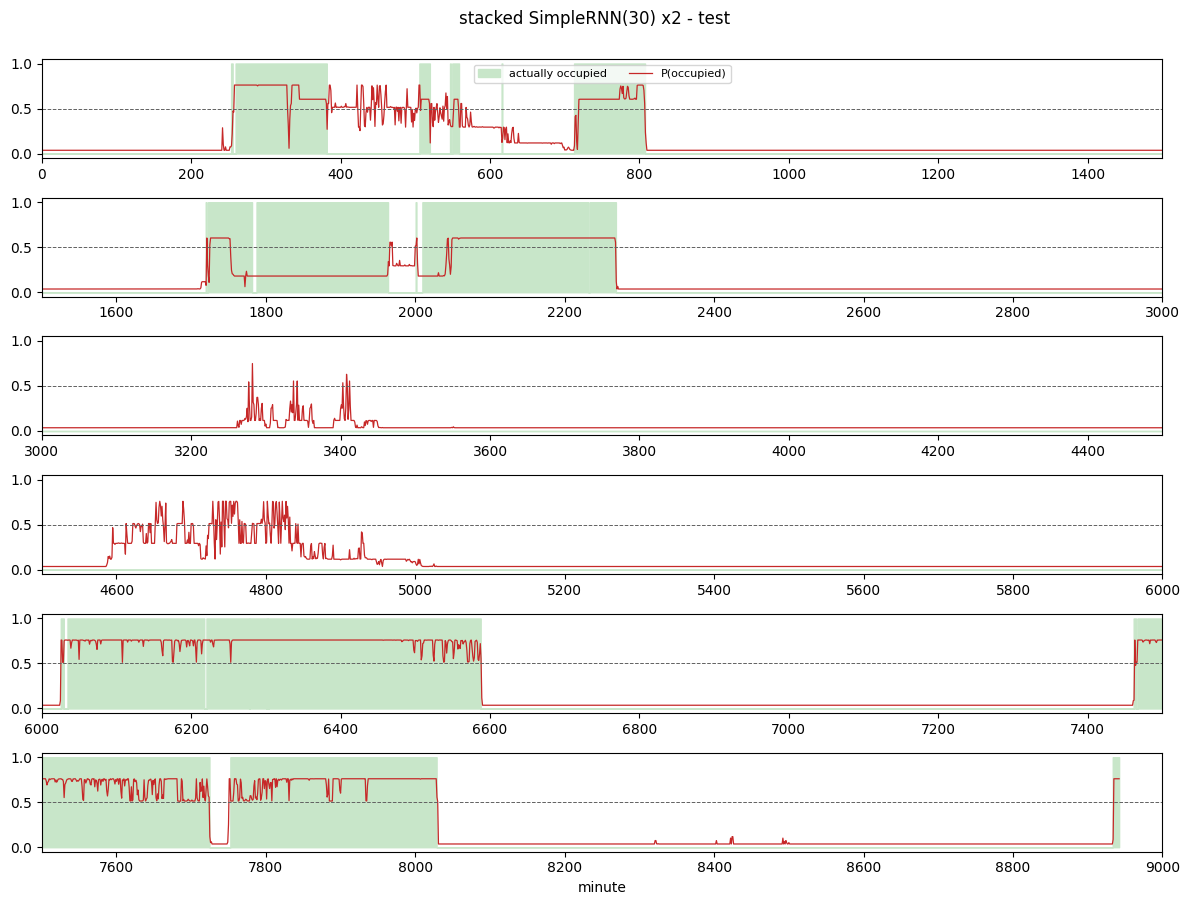

In [24]:
show_results("stacked SimpleRNN(30) x2", model)

## Save the model and use it again

Reproducibility means more than a seed: **save the fitted model** so you (or a teammate, or your future self) can reload it and predict without retraining. Keras 3 saves to a single `.keras` file. The reloaded model must give *identical* predictions - we check.

In [25]:
from keras.models import load_model

model.save('Multivariate_Occupancy_RNN.keras')                 # one file: architecture + weights + optimizer state
reloaded = load_model('Multivariate_Occupancy_RNN.keras')

# same inputs, same answers?
import numpy as np
same = np.allclose(model.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0))
print('reloaded model reproduces the predictions:', same)
reloaded.summary()

reloaded model reproduces the predictions: True


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 10, 30)         │         1,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,825 (34.48 KB)

 Trainable params: 2,941 (11.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,884 (22.99 KB)

## Did we beat the naive baselines?

Same question as the temperature notebook, and it matters more here, because **accuracy lies when the classes are
imbalanced**. The room is empty most of the time, so a model that never predicts "occupied" at all still scores
well on accuracy. That is why we report **weighted F1** and always print the confusion matrix.

In [26]:
# baseline model - prediction is just the previous time step (a tough one to beat!)
df['Baseline'] = df['Occupancy'].shift(1)
df.head()

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,Baseline
0,23.18,27.2720,426.0,721.25,0.004793,1,NaN
1,23.15,27.2675,429.5,714.00,0.004783,1,1.0
2,23.15,27.2450,426.0,713.50,0.004779,1,1.0
3,23.15,27.2000,426.0,708.25,0.004772,1,1.0
4,23.10,27.2000,426.0,704.50,0.004757,1,1.0


In [27]:
y_test_baseline = df['Baseline']
# just extract rows corresponding to y_test
y_test_baseline = y_test_baseline.tail(y_test.shape[0])
# verify shape
print(y_test.shape)
print(y_test_baseline.shape) # good!

(8943,)
(8943,)


### Baseline 1: always guess the majority class

The room is empty most of the time, so "it is always empty" is a surprisingly hard accuracy to beat - and a
completely useless model. This is the number that shows why accuracy alone is the wrong score.

In [28]:
from sklearn.metrics import accuracy_score

majority = int(round(y_train.mean()))          # whichever class dominates the TRAINING data
maj_test = np.full(len(y_test), majority)

print(f"the training set is {100*(1-y_train.mean()):.1f}% empty, so the majority guess is '{majority}'")
print(f"majority class:  accuracy = {accuracy_score(y_test, maj_test):.3f}"
      f"   weighted F1 = {f1_score(y_test, maj_test, average='weighted'):.3f}"
      f"   MACRO F1 = {f1_score(y_test, maj_test, average='macro'):.3f}  <- the one that catches it")
print("\nhigh accuracy, useless model - it never once says 'occupied':")
print(confusion_matrix(y_test, maj_test))
scores["majority class (always empty)"] = f1_score(y_test, maj_test, average="weighted")
macro["majority class (always empty)"]  = f1_score(y_test, maj_test, average="macro")

the training set is 78.4% empty, so the majority guess is '0'
majority class:  accuracy = 0.795   weighted F1 = 0.704   MACRO F1 = 0.443  <- the one that catches it

high accuracy, useless model - it never once says 'occupied':
[[7108    0]
 [1835    0]]


### Balanced vs imbalanced: why one score is not enough

The room is empty **78%** of the time, so the classes are badly imbalanced. That single fact is what makes
`accuracy` untrustworthy here, and the table below shows exactly where the three summary numbers come from so you
can see it rather than take my word for it.

$$\text{macro } F_1 = \frac{1}{C}\sum_c F_1^{(c)} \qquad\qquad
\text{weighted } F_1 = \frac{\sum_c n_c F_1^{(c)}}{\sum_c n_c}$$

Same per-class $F_1$ values, different weights. **Macro** gives the two classes equal say. **Weighted** gives every
*window* equal say, so the big class runs the show.

Run it on a real model and on the do-nothing baseline, and watch which number notices the difference.

In [29]:
print("=" * 62)
print("A REAL MODEL")
print("=" * 62)
m_model = metrics_table(y_test, (model.predict(X_test, verbose=0).ravel() >= 0.5))

print()
print("=" * 62)
print("THE DO-NOTHING BASELINE: always guess 'empty'")
print("=" * 62)
m_naive = metrics_table(y_test, np.zeros(len(y_test)))

print()
display(pd.DataFrame({"a real model": m_model, "always guess empty": m_naive}).round(3))
print("Accuracy barely drops. Weighted F1 gets suspicious. MACRO F1 collapses -")
print("because the 'occupied' class scores F1 = 0 and macro refuses to let the big class hide it.")
print("\nOn imbalanced data, quote MACRO when both classes matter - and here, catching the")
print("occupied minutes is the entire reason the sensor exists.")

A REAL MODEL


,TP,FP,FN,precision,recall,F1,support n_c,n_c x F1
class,,,,,,,,
empty,6846,266,262,0.9626,0.9631,0.9629,7108,6844.1
occupied,1569,262,266,0.8569,0.8550,0.8560,1835,1570.7


accuracy    = correct / all     = 8,415 / 8,943 = 0.9410
macro F1    = (F1_0 + F1_1) / 2 = (0.9629 + 0.8560) / 2 = 0.9094
weighted F1 = sum(n_c x F1) / N = 8,414.8 / 8,943 = 0.9409

THE DO-NOTHING BASELINE: always guess 'empty'


,TP,FP,FN,precision,recall,F1,support n_c,n_c x F1
class,,,,,,,,
empty,7108,1835,0,0.7948,1.0,0.8857,7108,6295.4
occupied,0,0,1835,0.0000,0.0,0.0000,1835,0.0


accuracy    = correct / all     = 7,108 / 8,943 = 0.7948
macro F1    = (F1_0 + F1_1) / 2 = (0.8857 + 0.0000) / 2 = 0.4429
weighted F1 = sum(n_c x F1) / N = 6,295.4 / 8,943 = 0.7039



,a real model,always guess empty
accuracy,0.941,0.795
macro F1,0.909,0.443
weighted F1,0.941,0.704


Accuracy barely drops. Weighted F1 gets suspicious. MACRO F1 collapses -
because the 'occupied' class scores F1 = 0 and macro refuses to let the big class hide it.

On imbalanced data, quote MACRO when both classes matter - and here, catching the
occupied minutes is the entire reason the sensor exists.


### Baseline 2: persistence (the previous minute)

"This minute looks like the one before it." On a room that stays occupied or empty for long stretches, this is a
very strong baseline - and that is the honest problem with this dataset, which we come back to at the end.

persistence: train F1 = 0.995   test F1 = 0.995


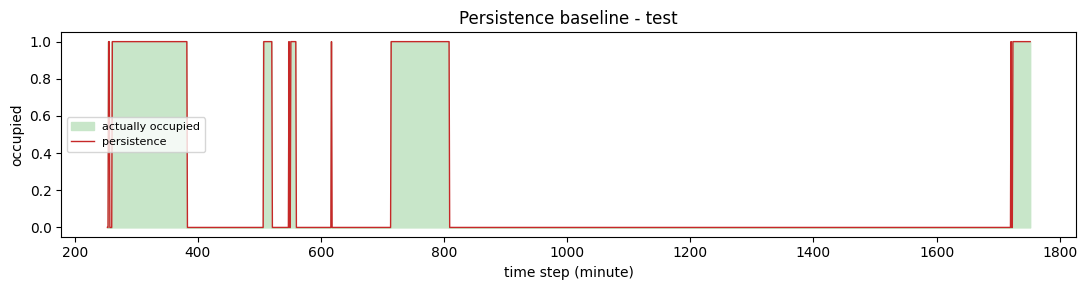

In [30]:
# the persistence baseline: predict that this minute looks like the previous one
base = df['Baseline'].values[n_steps - 1:]          # line it up with the windows split_sequences made
base_train, base_test = base[:train_pct_index], base[train_pct_index:train_pct_index + len(y_test)]

from sklearn.metrics import f1_score
print(f"persistence: train F1 = {f1_score(y_train, base_train, average='weighted'):.3f}"
      f"   test F1 = {f1_score(y_test, base_test, average='weighted'):.3f}")
scores['persistence (previous minute)'] = f1_score(y_test, base_test, average='weighted')
macro['persistence (previous minute)']  = f1_score(y_test, base_test, average='macro')

WIN = 1500
start = int(np.argmax(np.abs(np.diff(y_test)) > 0))
sl = slice(start, start + WIN); t = np.arange(len(y_test))[sl]
plt.figure(figsize=(11, 3))
plt.fill_between(t, 0, y_test[sl], step='mid', color='#C8E6C9', label='actually occupied')
plt.plot(t, base_test[sl], color='#C62828', lw=1.0, label='persistence')
plt.ylabel('occupied'); plt.xlabel('time step (minute)'); plt.legend(loc='center left', fontsize=8)
plt.title('Persistence baseline - test'); plt.tight_layout(); plt.show()

# looks good, BUT it's not a smart model! all it does is shift the answer by one minute.
# THIS is the number every model above has to beat.

### Baseline 3: no temporal information at all

Every model so far has been handed ten minutes of history. So here is the question that puts a number on whether
that history was worth anything: **what if the model only sees the current minute?**

Same rows, same split, same scoring - we just throw the window away and keep the last minute of it,
`X_train[:, -1, :]`. Five sensor readings, one occupancy label, no sequence, no lags. Two ordinary models: a random
forest and a one-hidden-layer dense net.

If these land near the recurrent models, then the ten-minute window was decoration.

In [31]:
from sklearn.ensemble import RandomForestClassifier

# keep ONLY the last row of each window: the current minute's five sensors, no history
X_now_train = X_train[:, -1, :]
X_now_test  = X_test[:,  -1, :]
print("with history:", X_train.shape, " -> without:", X_now_train.shape)

rf = RandomForestClassifier(n_estimators=100, random_state=5509).fit(X_now_train, y_train)
rf_pred = rf.predict(X_now_test)
scores["random forest (current minute only)"] = f1_score(y_test, rf_pred, average="weighted")
macro["random forest (current minute only)"]  = f1_score(y_test, rf_pred, average="macro")

dense_now = Sequential()
dense_now.add(Input(shape=(X_now_train.shape[1],)))
dense_now.add(Dense(30, activation="relu"))
dense_now.add(Dense(1, activation="sigmoid"))
dense_now.compile(optimizer="adam", loss="binary_crossentropy", metrics=["acc"])
dense_now.fit(X_now_train, y_train, epochs=50, batch_size=64, validation_split=0.2,
              callbacks=[es], verbose=0)
pred_now = (dense_now.predict(X_now_test, verbose=0).ravel() >= 0.5).astype(int)
scores["dense net (current minute only)"] = f1_score(y_test, pred_now, average="weighted")
macro["dense net (current minute only)"]  = f1_score(y_test, pred_now, average="macro")

for k in ["random forest (current minute only)", "dense net (current minute only)"]:
    print(f"{k:38s} test F1 = {scores[k]:.3f}")

with history: (8943, 10, 5)  -> without: (8943, 5)


Epoch 11: early stopping


Restoring model weights from the end of the best epoch: 1.


random forest (current minute only)    test F1 = 0.969
dense net (current minute only)        test F1 = 0.926


## The scoreboard

Every model and every baseline, ranked on the same test set. Read it from the top and it tells an uncomfortable
story about this dataset:

- **Persistence wins outright (0.995).** "This minute looks like the last one" is very hard to beat on a room that
  stays in one state for long stretches - and note that persistence is allowed to use past *occupancy*, which none
  of our models ever see.
- **A random forest on the current minute alone beats every recurrent model (0.969).** No window, no lags, no
  sequence - just five sensor readings from one instant. If throwing the history away makes the model *better*,
  the history was not carrying the signal.
- The recurrent models land in the middle, and stacking is the weakest of the three.

So this is really a **nowcasting problem dressed up as a sequence problem**: light and CO2 right now tell you
whether somebody is in the room. That is worth saying out loud to students - choosing the right model starts with
asking whether the data has the structure you are assuming.

It is also exactly why Module 4.3 moves to **electricity demand**, where yesterday genuinely does inform tomorrow
and a recurrent model has something to learn that a snapshot cannot give it.

In [32]:
board = pd.DataFrame({"weighted F1": pd.Series(scores), "MACRO F1": pd.Series(macro)})
board.sort_values("MACRO F1", ascending=False).round(3)

,weighted F1,MACRO F1
persistence (previous minute),0.995,0.992
random forest (current minute only),0.969,0.954
LSTM(30),0.953,0.928
SimpleRNN(30),0.952,0.926
stacked SimpleRNN(30) x2,0.941,0.909
dense net (current minute only),0.926,0.888
majority class (always empty),0.704,0.443


In [33]:
# be careful of the baseline model
# and make sure you choose an appropriate measure
# for the problem you are trying to solve...